In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("task-1-Womens-Clothing-E-Commerce-Reviews.csv")
df

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [3]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 23486
Columns: 11


In [5]:
print(df.columns)

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='str')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB


Missing Values in Each Column:
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Missing Percentage:
Unnamed: 0                  0.00
Clothing ID                 0.00
Age                         0.00
Title                      16.22
Review Text                 3.60
Rating                      0.00
Recommended IND             0.00
Positive Feedback Count     0.00
Division Name               0.06
Department Name             0.06
Class Name                  0.06
dtype: float64

Missing Value Summary:


,Missing Values,Missing Percentage
Title,3810,16.222430
Review Text,845,3.597888
Division Name,14,0.059610
Department Name,14,0.059610
Class Name,14,0.059610


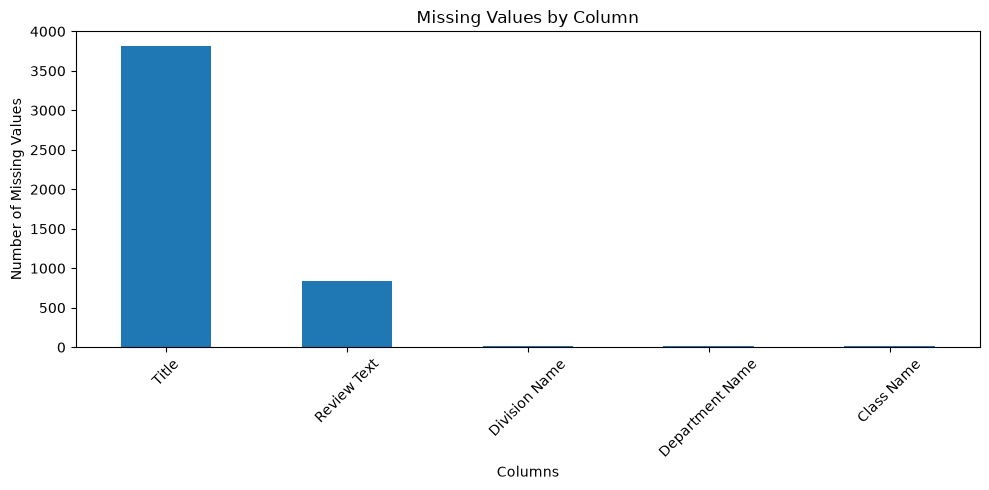

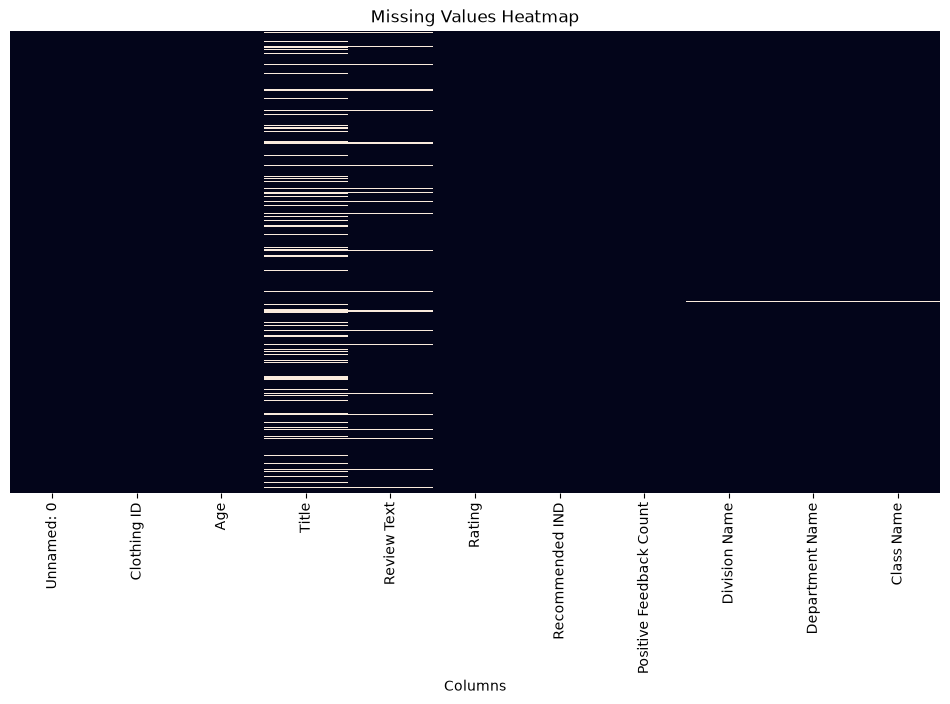

In [7]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Percentage:")
print(missing_percentage.round(2))

missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_table = missing_table[
    missing_table['Missing Values'] > 0
]

print("\nMissing Value Summary:")
display(missing_table)

plt.figure(figsize=(10, 5))

missing_table['Missing Values'].sort_values(
    ascending=False
).plot(kind='bar')

plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.show()

In [8]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print(df.columns.tolist())

['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


In [9]:
print("Data Types of Each Column:")
print(df.dtypes)

Data Types of Each Column:
Clothing ID                int64
Age                        int64
Title                        str
Review Text                  str
Rating                     int64
Recommended IND            int64
Positive Feedback Count    int64
Division Name                str
Department Name              str
Class Name                   str
dtype: object


In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical/Text Columns:")
print(categorical_cols)

Numerical Columns:
['Clothing ID', 'Age', 'Rating', 'Recommended IND', 'Positive Feedback Count']

Categorical/Text Columns:
['Title', 'Review Text', 'Division Name', 'Department Name', 'Class Name']


C:\Users\panch\AppData\Local\Temp\ipykernel_484\3897581050.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [11]:
text_cols = ['Title', 'Review Text']

categorical_cols = [
    col for col in df.select_dtypes(include=['object', 'category']).columns
    if col not in text_cols
]

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

print("\nText Columns:")
print(text_cols)

Numerical Columns:
['Clothing ID', 'Age', 'Rating', 'Recommended IND', 'Positive Feedback Count']

Categorical Columns:
['Division Name', 'Department Name', 'Class Name']

Text Columns:
['Title', 'Review Text']


C:\Users\panch\AppData\Local\Temp\ipykernel_484\2783284167.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df.select_dtypes(include=['object', 'category']).columns


In [12]:
numerical_stats = df[numerical_cols].describe().T

print("Numerical Statistical Summary:")
display(numerical_stats)

Numerical Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Clothing ID,23486.0,918.118709,203.298980,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0


In [13]:
stats_analysis = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Std Dev': df[numerical_cols].std(),
    'Skewness': df[numerical_cols].skew()
})

display(stats_analysis)

,Mean,Median,Std Dev,Skewness
Clothing ID,918.118709,936.0,203.298980,-2.087636
Age,43.198544,41.0,12.279544,0.525615
Rating,4.196032,5.0,1.110031,-1.313529
Recommended IND,0.822362,1.0,0.382216,-1.686952
Positive Feedback Count,2.535936,1.0,5.702202,6.472998


In [14]:
correlation_matrix = df[numerical_cols].corr()

display(correlation_matrix)

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
Clothing ID,1.000000,0.017972,-0.018879,-0.016206,0.046356
Age,0.017972,1.000000,0.026831,0.030622,0.043079
Rating,-0.018879,0.026831,1.000000,0.792336,-0.064961
Recommended IND,-0.016206,0.030622,0.792336,1.000000,-0.069045
Positive Feedback Count,0.046356,0.043079,-0.064961,-0.069045,1.000000


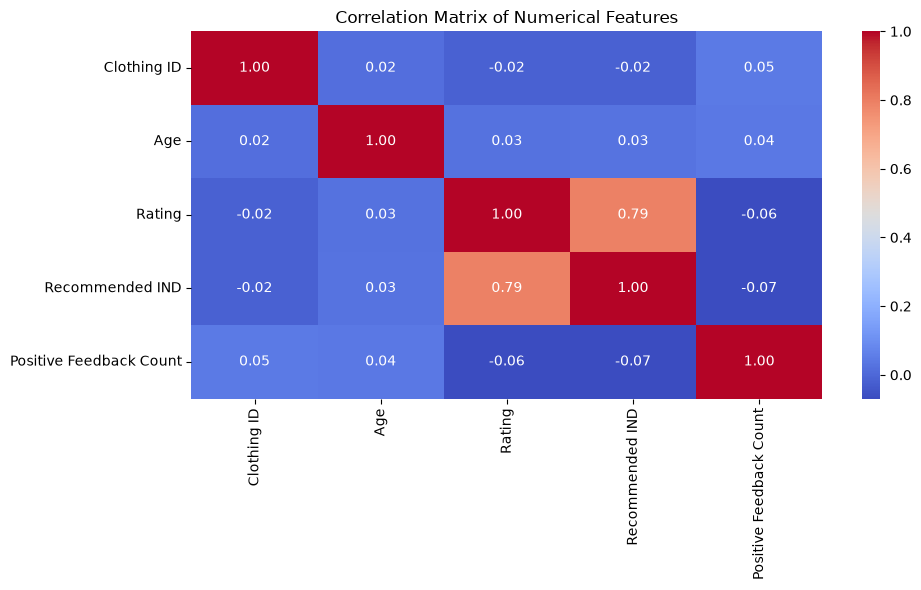

In [15]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [16]:
for col in categorical_cols:
    print("\n", "="*50)
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))


Division Name
Unique values: 3
Division Name
General           13850
General Petite     8120
Initmates          1502
NaN                  14
Name: count, dtype: int64

Department Name
Unique values: 6
Department Name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
NaN            14
Name: count, dtype: int64

Class Name
Unique values: 20
Class Name
Dresses       6319
Knits         4843
Blouses       3097
Sweaters      1428
Pants         1388
Jeans         1147
Fine gauge    1100
Skirts         945
Jackets        704
Lounge         691
Name: count, dtype: int64


In [17]:
missing_categorical = df[
    df[['Division Name', 'Department Name', 'Class Name']].isnull().any(axis=1)
]

display(missing_categorical)

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
9444,72,25,My favorite socks!!!,"I never write reviews, but these socks are so ...",5,1,0,NaN,NaN,NaN
13767,492,23,So soft!,I just love this hoodie! it is so soft and com...,5,1,1,NaN,NaN,NaN
13768,492,49,Wardrobe staple,Love this hoodie. so soft and goes with everyt...,5,1,0,NaN,NaN,NaN
13787,492,48,NaN,NaN,5,1,0,NaN,NaN,NaN
16216,152,36,Warm and cozy,"Just what i was looking for. soft, cozy and warm.",5,1,0,NaN,NaN,NaN
16221,152,37,Love!,I am loving these. they are quite long but are...,5,1,0,NaN,NaN,NaN
16223,152,39,"""long and warm""",These leg warmers are perfect for me. they are...,5,1,0,NaN,NaN,NaN
18626,184,34,Nubby footless tights,"These are amazing quality. i agree, size up to...",5,1,5,NaN,NaN,NaN
18671,184,54,New workhorse,These tights are amazing! if i care for them w...,5,1,0,NaN,NaN,NaN
20088,772,50,Comfy sweatshirt!,This sweatshirt is really nice! it's oversize...,5,1,0,NaN,NaN,NaN


In [18]:
knn_features = [
    'Age',
    'Rating',
    'Recommended IND',
    'Positive Feedback Count'
]

print("Features used for KNN:")
print(knn_features)

def evaluate_knn(target_column, random_state=42):

    original_values = df[target_column].copy()

    test_indices = df.sample(
        frac=0.10,
        random_state=random_state
    ).index

    temp_df = df[knn_features].copy()

    temp_df.loc[
        test_indices,
        target_column
    ] = np.nan

    scaler = StandardScaler()

    scaled_data = scaler.fit_transform(temp_df)

    imputer = KNNImputer(
        n_neighbors=5
    )

    imputed_scaled = imputer.fit_transform(
        scaled_data
    )

    imputed_data = scaler.inverse_transform(
        imputed_scaled
    )

    imputed_df = pd.DataFrame(
        imputed_data,
        columns=knn_features,
        index=df.index
    )

    actual = original_values.loc[test_indices]

    predicted = imputed_df.loc[
        test_indices,
        target_column
    ]

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    return mae, rmse, actual, predicted

mae_age, rmse_age, actual_age, predicted_age = evaluate_knn(
    'Age'
)

mae_feedback, rmse_feedback, actual_feedback, predicted_feedback = evaluate_knn(
    'Positive Feedback Count'
)

knn_results = pd.DataFrame({
    'Column': [
        'Age',
        'Positive Feedback Count'
    ],
    'MAE': [
        mae_age,
        mae_feedback
    ],
    'RMSE': [
        rmse_age,
        rmse_feedback
    ]
})

print("\nKNN IMPUTATION RESULTS")
print("======================")

display(knn_results.round(3))

Features used for KNN:
['Age', 'Rating', 'Recommended IND', 'Positive Feedback Count']

KNN IMPUTATION RESULTS


,Column,MAE,RMSE
0,Age,10.935,13.426
1,Positive Feedback Count,5.604,9.145


In [19]:
mice_features = [
    'Age',
    'Rating',
    'Recommended IND',
    'Positive Feedback Count'
]

print("Features used for MICE:")
print(mice_features)

def evaluate_mice(target_column, random_state=42):

    original_values = df[target_column].copy()

    test_indices = df.sample(
        frac=0.10,
        random_state=random_state
    ).index

    temp_df = df[mice_features].copy()

    temp_df.loc[
        test_indices,
        target_column
    ] = np.nan

    scaler = StandardScaler()

    scaled_data = scaler.fit_transform(temp_df)

    imputer = IterativeImputer(
        max_iter=10,
        random_state=42
    )

    imputed_scaled = imputer.fit_transform(
        scaled_data
    )

    imputed_data = scaler.inverse_transform(
        imputed_scaled
    )

    imputed_df = pd.DataFrame(
        imputed_data,
        columns=mice_features,
        index=df.index
    )

    actual = original_values.loc[
        test_indices
    ]

    predicted = imputed_df.loc[
        test_indices,
        target_column
    ]

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    return mae, rmse, actual, predicted

mae_age_mice, rmse_age_mice, actual_age_mice, predicted_age_mice = evaluate_mice(
    'Age'
)

mae_feedback_mice, rmse_feedback_mice, actual_feedback_mice, predicted_feedback_mice = evaluate_mice(
    'Positive Feedback Count'
)

mice_results = pd.DataFrame({
    'Column': [
        'Age',
        'Positive Feedback Count'
    ],
    'MAE': [
        mae_age_mice,
        mae_feedback_mice
    ],
    'RMSE': [
        rmse_age_mice,
        rmse_feedback_mice
    ]
})

print("\nMICE IMPUTATION RESULTS")
print("=======================")

display(mice_results.round(3))

Features used for MICE:
['Age', 'Rating', 'Recommended IND', 'Positive Feedback Count']

MICE IMPUTATION RESULTS


,Column,MAE,RMSE
0,Age,10.003,12.323
1,Positive Feedback Count,3.024,5.777


In [20]:
def evaluate_predictive_model(target_column, random_state=42):

    features = [
        'Age',
        'Rating',
        'Recommended IND',
        'Positive Feedback Count'
    ]

    predictor_columns = [
        col for col in features
        if col != target_column
    ]

    test_indices = df.sample(
        frac=0.10,
        random_state=random_state
    ).index

    train_indices = df.index.difference(
        test_indices
    )

    X_train = df.loc[
        train_indices,
        predictor_columns
    ]

    y_train = df.loc[
        train_indices,
        target_column
    ]

    X_test = df.loc[
        test_indices,
        predictor_columns
    ]

    y_test = df.loc[
        test_indices,
        target_column
    ]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    predicted = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predicted
        )
    )

    return mae, rmse, y_test, predicted

mae_age_pred, rmse_age_pred, actual_age_pred, predicted_age_pred = (
    evaluate_predictive_model('Age')
)

mae_feedback_pred, rmse_feedback_pred, actual_feedback_pred, predicted_feedback_pred = (
    evaluate_predictive_model('Positive Feedback Count')
)

predictive_results = pd.DataFrame({

    'Column': [
        'Age',
        'Positive Feedback Count'
    ],

    'MAE': [
        mae_age_pred,
        mae_feedback_pred
    ],

    'RMSE': [
        rmse_age_pred,
        rmse_feedback_pred
    ]
})

print("PREDICTIVE MODELING RESULTS")
print("===========================")

display(
    predictive_results.round(3)
)

PREDICTIVE MODELING RESULTS


,Column,MAE,RMSE
0,Age,10.034,12.381
1,Positive Feedback Count,3.050,5.796


In [21]:
comparison_results = pd.DataFrame({
    'Column': [
        'Age', 'Age', 'Age',
        'Positive Feedback Count',
        'Positive Feedback Count',
        'Positive Feedback Count'
    ],

    'Method': [
        'KNN',
        'MICE',
        'Predictive Modeling',
        'KNN',
        'MICE',
        'Predictive Modeling'
    ],

    'MAE': [
        mae_age,
        mae_age_mice,
        mae_age_pred,
        mae_feedback,
        mae_feedback_mice,
        mae_feedback_pred
    ],

    'RMSE': [
        rmse_age,
        rmse_age_mice,
        rmse_age_pred,
        rmse_feedback,
        rmse_feedback_mice,
        rmse_feedback_pred
    ]
})

display(comparison_results.round(3))

,Column,Method,MAE,RMSE
0,Age,KNN,10.935,13.426
1,Age,MICE,10.003,12.323
2,Age,Predictive Modeling,10.034,12.381
3,Positive Feedback Count,KNN,5.604,9.145
4,Positive Feedback Count,MICE,3.024,5.777
5,Positive Feedback Count,Predictive Modeling,3.050,5.796


In [22]:
best_mae = comparison_results.loc[
    comparison_results.groupby('Column')['MAE'].idxmin()
]

print("Best Method Based on MAE:")
display(best_mae[['Column', 'Method', 'MAE']])

Best Method Based on MAE:


,Column,Method,MAE
1,Age,MICE,10.002640
4,Positive Feedback Count,MICE,3.023765


In [23]:
best_rmse = comparison_results.loc[
    comparison_results.groupby('Column')['RMSE'].idxmin()
]

print("Best Method Based on RMSE:")
display(best_rmse[['Column', 'Method', 'RMSE']])

Best Method Based on RMSE:


,Column,Method,RMSE
1,Age,MICE,12.322995
4,Positive Feedback Count,MICE,5.776803


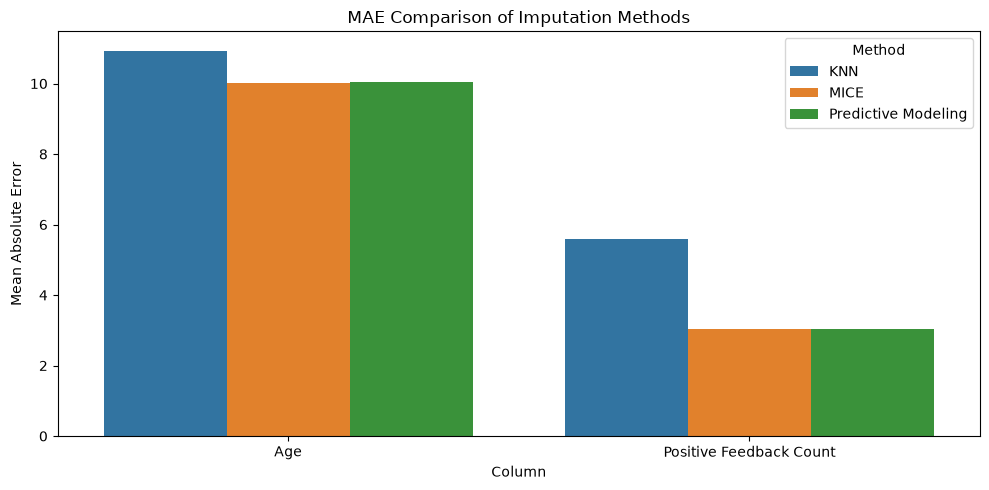

In [24]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=comparison_results,
    x='Column',
    y='MAE',
    hue='Method'
)

plt.title('MAE Comparison of Imputation Methods')
plt.xlabel('Column')
plt.ylabel('Mean Absolute Error')
plt.tight_layout()
plt.show()

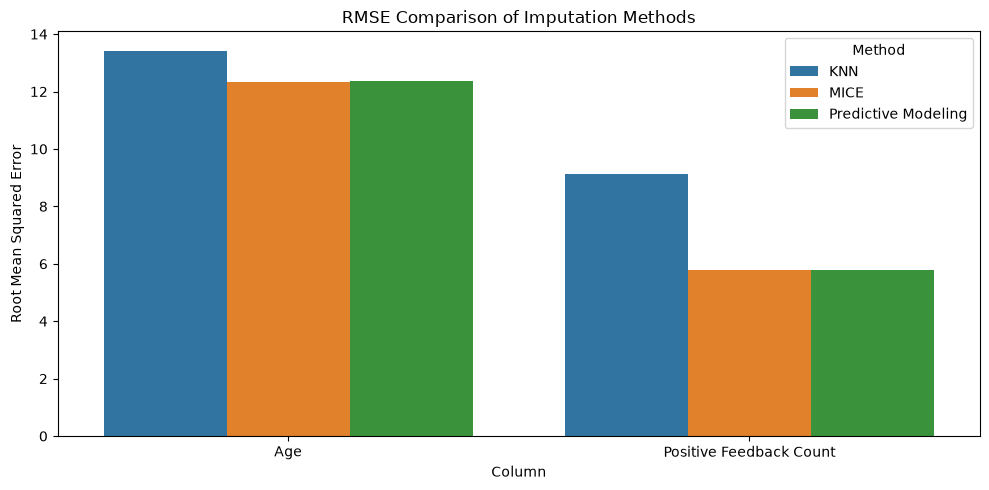

In [25]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=comparison_results,
    x='Column',
    y='RMSE',
    hue='Method'
)

plt.title('RMSE Comparison of Imputation Methods')
plt.xlabel('Column')
plt.ylabel('Root Mean Squared Error')
plt.tight_layout()
plt.show()

In [26]:
age_improvement = (
    (mae_age - mae_age_mice) / mae_age
) * 100

print(
    "Age - MICE improvement over KNN:",
    round(age_improvement, 2),
    "%"
)

Age - MICE improvement over KNN: 8.52 %


In [27]:
feedback_improvement = (
    (mae_feedback - mae_feedback_mice)
    / mae_feedback
) * 100

print(
    "Positive Feedback - MICE improvement over KNN:",
    round(feedback_improvement, 2),
    "%"
)

Positive Feedback - MICE improvement over KNN: 46.04 %


In [28]:
df_clean = df.copy()

print("Missing values before cleaning:")
print(df_clean.isnull().sum())

Missing values before cleaning:
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


In [29]:
df_clean['Title_Missing_Flag'] = (
    df_clean['Title'].isnull().astype(int)
)

df_clean['Title'] = df_clean['Title'].fillna('No Title')

In [30]:
print("Missing Title after filling:")
print(df_clean['Title'].isnull().sum())

print("\nOriginally missing Titles:")
print(df_clean['Title_Missing_Flag'].sum())

Missing Title after filling:
0

Originally missing Titles:
3810


In [31]:
df_clean['Review_Text_Missing_Flag'] = (
    df_clean['Review Text'].isnull().astype(int)
)

df_clean['Review Text'] = (
    df_clean['Review Text'].fillna('No Review')
)

In [32]:
print("Missing Review Text after filling:")
print(df_clean['Review Text'].isnull().sum())

print("\nOriginally missing Reviews:")
print(df_clean['Review_Text_Missing_Flag'].sum())

Missing Review Text after filling:
0

Originally missing Reviews:
845


In [33]:
categorical_missing_cols = [
    'Division Name',
    'Department Name',
    'Class Name'
]

def fill_by_clothing_id(data, column):

    mapping = (
        data.dropna(subset=[column])
            .groupby('Clothing ID')[column]
            .agg(lambda x: x.mode().iloc[0])
    )

    missing_mask = data[column].isnull()

    data.loc[missing_mask, column] = (
        data.loc[missing_mask, 'Clothing ID']
            .map(mapping)
    )

    return data

In [34]:
for col in categorical_missing_cols:

    df_clean = fill_by_clothing_id(
        df_clean,
        col
    )

print("Missing values after Clothing ID based imputation:")

print(
    df_clean[categorical_missing_cols]
    .isnull()
    .sum()
)

Missing values after Clothing ID based imputation:
Division Name      14
Department Name    14
Class Name         14
dtype: int64


In [35]:
for col in categorical_missing_cols:

    if df_clean[col].isnull().sum() > 0:

        mode_value = df_clean[col].mode()[0]

        df_clean[col] = (
            df_clean[col].fillna(mode_value)
        )

In [36]:
print("Categorical missing values after final treatment:")

print(
    df_clean[categorical_missing_cols]
    .isnull()
    .sum()
)

Categorical missing values after final treatment:
Division Name      0
Department Name    0
Class Name         0
dtype: int64


In [37]:
print("FINAL MISSING VALUE CHECK")
print("=========================")

final_missing = df_clean.isnull().sum()

print(final_missing)

print(
    "\nTotal Missing Values:",
    final_missing.sum()
)

FINAL MISSING VALUE CHECK
Clothing ID                 0
Age                         0
Title                       0
Review Text                 0
Rating                      0
Recommended IND             0
Positive Feedback Count     0
Division Name               0
Department Name             0
Class Name                  0
Title_Missing_Flag          0
Review_Text_Missing_Flag    0
dtype: int64

Total Missing Values: 0


In [38]:
before_missing = df.isnull().sum()

after_missing = df_clean.isnull().sum()

missing_comparison = pd.DataFrame({
    'Before Imputation': before_missing,
    'After Imputation': after_missing
})

display(missing_comparison)

,Before Imputation,After Imputation
Age,0.0,0
Class Name,14.0,0
Clothing ID,0.0,0
Department Name,14.0,0
Division Name,14.0,0
Positive Feedback Count,0.0,0
Rating,0.0,0
Recommended IND,0.0,0
Review Text,845.0,0
Review_Text_Missing_Flag,NaN,0


In [39]:
cleaned_categorical_rows = df_clean.loc[missing_categorical.index]

display(
    cleaned_categorical_rows[
        [
            'Clothing ID',
            'Division Name',
            'Department Name',
            'Class Name'
        ]
    ]
)

,Clothing ID,Division Name,Department Name,Class Name
9444,72,General,Tops,Dresses
13767,492,General,Tops,Dresses
13768,492,General,Tops,Dresses
13787,492,General,Tops,Dresses
16216,152,General,Tops,Dresses
16221,152,General,Tops,Dresses
16223,152,General,Tops,Dresses
18626,184,General,Tops,Dresses
18671,184,General,Tops,Dresses
20088,772,General,Tops,Dresses


In [40]:
df_clean.to_csv(
    'Womens_Clothing_Cleaned.csv',
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [41]:
before_missing = df.isnull().sum()

after_missing = df_clean.isnull().sum()

missing_comparison = pd.DataFrame({
    'Before Cleaning': before_missing,
    'After Cleaning': after_missing
})

display(missing_comparison)

,Before Cleaning,After Cleaning
Age,0.0,0
Class Name,14.0,0
Clothing ID,0.0,0
Department Name,14.0,0
Division Name,14.0,0
Positive Feedback Count,0.0,0
Rating,0.0,0
Recommended IND,0.0,0
Review Text,845.0,0
Review_Text_Missing_Flag,NaN,0


In [42]:
print("Total Missing Values Before Cleaning:",
      df.isnull().sum().sum())

print("Total Missing Values After Cleaning:",
      df_clean.isnull().sum().sum())

Total Missing Values Before Cleaning: 4697
Total Missing Values After Cleaning: 0


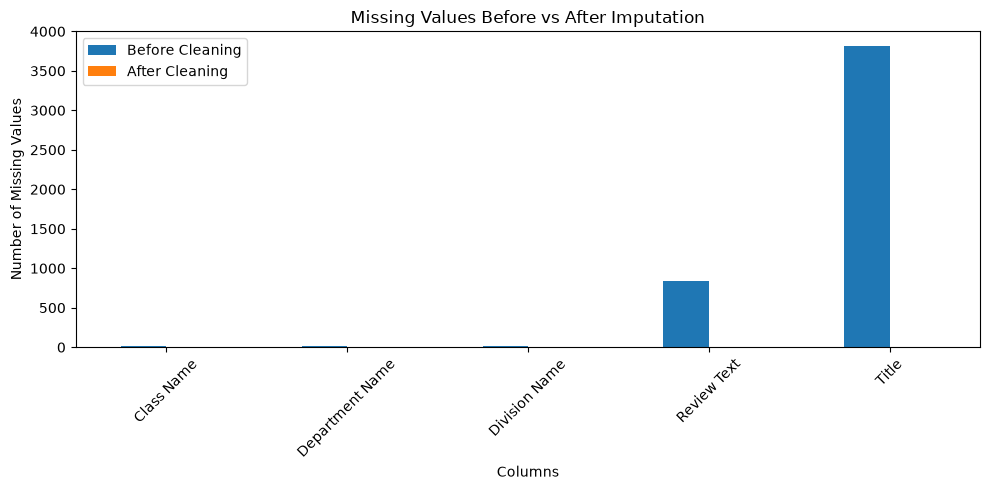

In [43]:
missing_plot = missing_comparison[
    missing_comparison['Before Cleaning'] > 0
]

missing_plot.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Missing Values Before vs After Imputation')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
numeric_cols = [
    'Age',
    'Rating',
    'Recommended IND',
    'Positive Feedback Count'
]

before_stats = df[numeric_cols].agg(
    ['mean', 'median', 'std']
).T

after_stats = df_clean[numeric_cols].agg(
    ['mean', 'median', 'std']
).T

print("BEFORE CLEANING:")
display(before_stats.round(3))

print("AFTER CLEANING:")
display(after_stats.round(3))

BEFORE CLEANING:


,mean,median,std
Age,43.199,41.0,12.280
Rating,4.196,5.0,1.110
Recommended IND,0.822,1.0,0.382
Positive Feedback Count,2.536,1.0,5.702


AFTER CLEANING:


,mean,median,std
Age,43.199,41.0,12.280
Rating,4.196,5.0,1.110
Recommended IND,0.822,1.0,0.382
Positive Feedback Count,2.536,1.0,5.702


In [45]:
stat_comparison = pd.DataFrame({
    'Mean Before': df[numeric_cols].mean(),
    'Mean After': df_clean[numeric_cols].mean(),

    'Median Before': df[numeric_cols].median(),
    'Median After': df_clean[numeric_cols].median(),

    'Std Before': df[numeric_cols].std(),
    'Std After': df_clean[numeric_cols].std()
})

display(stat_comparison.round(3))

,Mean Before,Mean After,Median Before,Median After,Std Before,Std After
Age,43.199,43.199,41.0,41.0,12.280,12.280
Rating,4.196,4.196,5.0,5.0,1.110,1.110
Recommended IND,0.822,0.822,1.0,1.0,0.382,0.382
Positive Feedback Count,2.536,2.536,1.0,1.0,5.702,5.702


In [46]:
categorical_cols = [
    'Division Name',
    'Department Name',
    'Class Name'
]

for col in categorical_cols:

    print("\n", "=" * 50)
    print(col)
    print("=" * 50)

    comparison = pd.DataFrame({
        'Before': df[col].value_counts(),
        'After': df_clean[col].value_counts()
    }).fillna(0)

    display(comparison)


Division Name


,Before,After
Division Name,,
General,13850,13864
General Petite,8120,8120
Initmates,1502,1502



Department Name


,Before,After
Department Name,,
Tops,10468,10482
Dresses,6319,6319
Bottoms,3799,3799
Intimate,1735,1735
Jackets,1032,1032
Trend,119,119



Class Name


,Before,After
Class Name,,
Dresses,6319,6333
Knits,4843,4843
Blouses,3097,3097
Sweaters,1428,1428
Pants,1388,1388
Jeans,1147,1147
Fine gauge,1100,1100
Skirts,945,945
Jackets,704,704


In [47]:
method_results = pd.DataFrame({
    'Column': [
        'Age', 'Age', 'Age',
        'Positive Feedback Count',
        'Positive Feedback Count',
        'Positive Feedback Count'
    ],

    'Method': [
        'KNN',
        'MICE',
        'Predictive Modeling',
        'KNN',
        'MICE',
        'Predictive Modeling'
    ],

    'MAE': [
        10.935,
        10.003,
        10.034,
        5.604,
        3.024,
        3.050
    ],

    'RMSE': [
        13.426,
        12.323,
        12.381,
        9.145,
        5.777,
        5.796
    ]
})

display(method_results)

,Column,Method,MAE,RMSE
0,Age,KNN,10.935,13.426
1,Age,MICE,10.003,12.323
2,Age,Predictive Modeling,10.034,12.381
3,Positive Feedback Count,KNN,5.604,9.145
4,Positive Feedback Count,MICE,3.024,5.777
5,Positive Feedback Count,Predictive Modeling,3.050,5.796


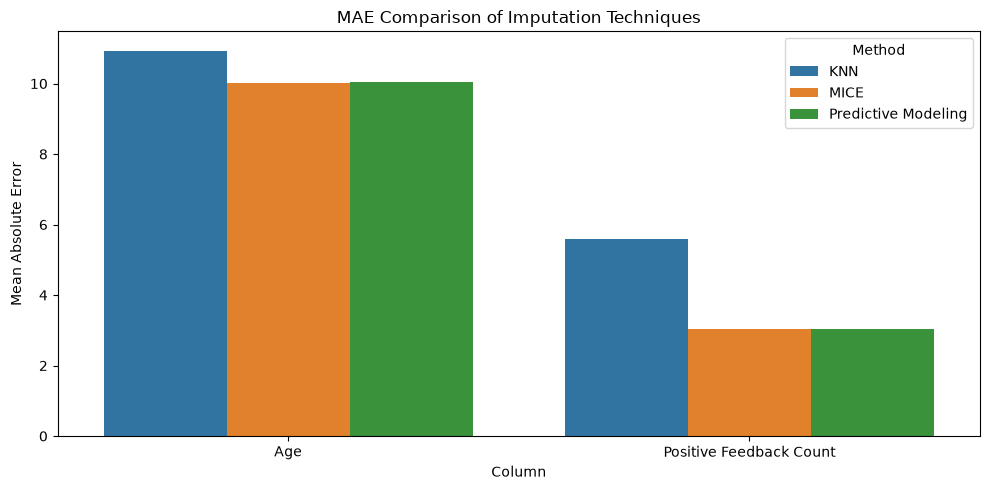

In [48]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=method_results,
    x='Column',
    y='MAE',
    hue='Method'
)

plt.title('MAE Comparison of Imputation Techniques')
plt.xlabel('Column')
plt.ylabel('Mean Absolute Error')
plt.tight_layout()
plt.show()

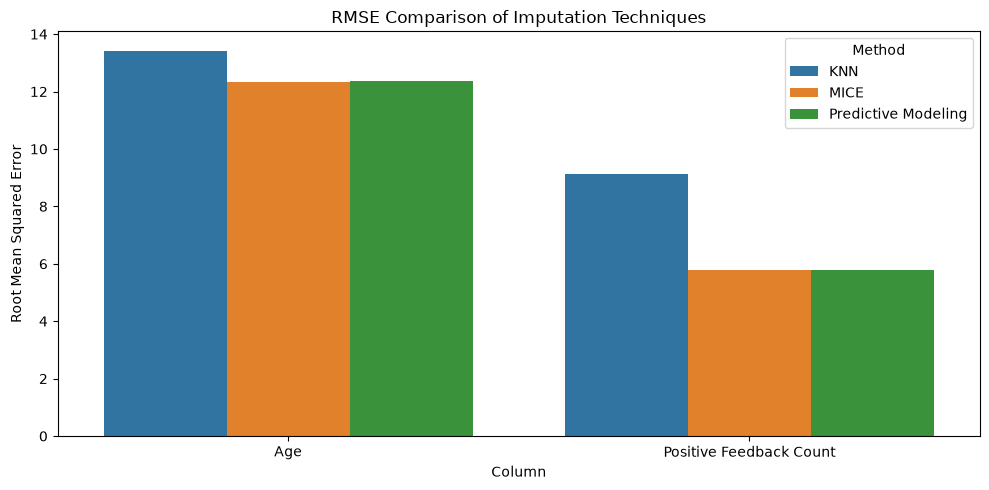

In [49]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=method_results,
    x='Column',
    y='RMSE',
    hue='Method'
)

plt.title('RMSE Comparison of Imputation Techniques')
plt.xlabel('Column')
plt.ylabel('Root Mean Squared Error')
plt.tight_layout()
plt.show()

In [50]:
final_selection = pd.DataFrame({

    'Column': [
        'Age (Experimental)',
        'Positive Feedback Count (Experimental)',
        'Title',
        'Review Text',
        'Division Name',
        'Department Name',
        'Class Name'
    ],

    'Data Type': [
        'Numerical',
        'Numerical',
        'Text',
        'Text',
        'Categorical',
        'Categorical',
        'Categorical'
    ],

    'Selected Method': [
        'MICE',
        'MICE',
        'Missing Label + Indicator',
        'Missing Label + Indicator',
        'Clothing ID Based Imputation',
        'Clothing ID Based Imputation',
        'Clothing ID Based Imputation'
    ]
})

display(final_selection)

,Column,Data Type,Selected Method
0,Age (Experimental),Numerical,MICE
1,Positive Feedback Count (Experimental),Numerical,MICE
2,Title,Text,Missing Label + Indicator
3,Review Text,Text,Missing Label + Indicator
4,Division Name,Categorical,Clothing ID Based Imputation
5,Department Name,Categorical,Clothing ID Based Imputation
6,Class Name,Categorical,Clothing ID Based Imputation


In [51]:
print("Final Dataset Shape:", df_clean.shape)

print("\nTotal Missing Values:")
print(df_clean.isnull().sum().sum())

print("\nMissing Values Column-wise:")
print(df_clean.isnull().sum())

Final Dataset Shape: (23486, 12)

Total Missing Values:
0

Missing Values Column-wise:
Clothing ID                 0
Age                         0
Title                       0
Review Text                 0
Rating                      0
Recommended IND             0
Positive Feedback Count     0
Division Name               0
Department Name             0
Class Name                  0
Title_Missing_Flag          0
Review_Text_Missing_Flag    0
dtype: int64


In [52]:
final_methods = pd.DataFrame({
    'Column': [
        'Age',
        'Positive Feedback Count',
        'Title',
        'Review Text',
        'Division Name',
        'Department Name',
        'Class Name'
    ],

    'Type': [
        'Numerical',
        'Numerical',
        'Text',
        'Text',
        'Categorical',
        'Categorical',
        'Categorical'
    ],

    'Missing Status': [
        'Experimental Masking',
        'Experimental Masking',
        'Actual Missing',
        'Actual Missing',
        'Actual Missing',
        'Actual Missing',
        'Actual Missing'
    ],

    'Selected Method': [
        'MICE',
        'MICE',
        'Missing Label + Indicator',
        'Missing Label + Indicator',
        'Clothing ID Based Imputation',
        'Clothing ID Based Imputation',
        'Clothing ID Based Imputation'
    ]
})

display(final_methods)

,Column,Type,Missing Status,Selected Method
0,Age,Numerical,Experimental Masking,MICE
1,Positive Feedback Count,Numerical,Experimental Masking,MICE
2,Title,Text,Actual Missing,Missing Label + Indicator
3,Review Text,Text,Actual Missing,Missing Label + Indicator
4,Division Name,Categorical,Actual Missing,Clothing ID Based Imputation
5,Department Name,Categorical,Actual Missing,Clothing ID Based Imputation
6,Class Name,Categorical,Actual Missing,Clothing ID Based Imputation


In [53]:
df_clean.to_csv(
    "Womens_Clothing_Cleaned.csv",
    index=False
)

print("Final cleaned dataset saved successfully.")

Final cleaned dataset saved successfully.
